In [70]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

gen_mean_std = np.load('/Users/isaaclee/Wildfire_Research/lognorm_wildfire_results/depth_4_epochs_10000_schedule_VE_sigma_2/generated_mean_std.npz')
real_samples = np.load('/Users/isaaclee/Wildfire_Research/lognorm_wildfire_results/depth_4_epochs_10000_schedule_VE_sigma_2/real_samples.npz')
gen_samples = np.load('/Users/isaaclee/Wildfire_Research/lognorm_wildfire_results/depth_4_epochs_10000_schedule_VE_sigma_2/generated_samples.npz')['arr_0']

pred_means = gen_mean_std['array1']
real_samples = real_samples['arr_0']

x3_log_max = np.load('/Users/isaaclee/Wildfire_Research/recursive_data/lognorm_x3_log_max.npy')

#print(f'Smallest ensemble member: {min(gen_samples[:,2])}')

# unnormalize
real = np.exp(real_samples[:, 2] * x3_log_max) - 1
pred = np.exp(np.clip(pred_means[:, 2], 0, None) * x3_log_max) - 1

print("LOGNORM METRICS")
print("="*50)

mape = np.mean(np.abs(real - pred) / real)
print(f"MAPE: {mape}")

mdape = np.median(np.abs(real-pred)/real)
print(f"MdAPE: {mdape}")

dist_x3 = np.exp(np.clip(gen_samples[:,2], 0, None) * x3_log_max) - 1
# print(min(dist_x3))
dist_x3 = dist_x3.reshape(1200,1000)
std_x3 = np.std(dist_x3, axis=1)

within_1_std = np.abs(real-pred) <= std_x3
proportions = within_1_std.astype(int)
print(f'Withind 1 std: {np.mean(proportions)}')

print(f'Standard deviation: {np.mean(std_x3)}')

LOGNORM METRICS
MAPE: 0.49039004481039117
MdAPE: 0.4087093340857651
Withind 1 std: 0.2875
Standard deviation: 82.45838568880177


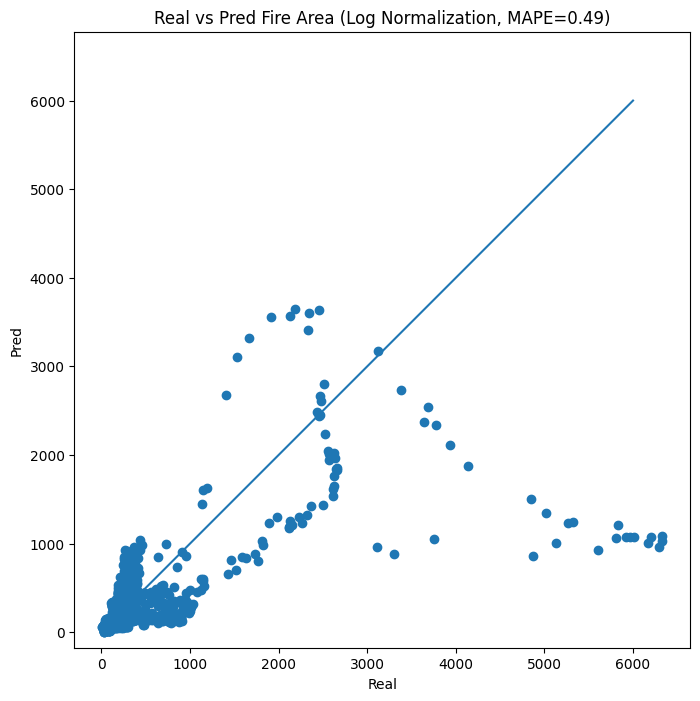

In [71]:
plt.figure(figsize=(8,8))
plt.scatter(real, pred)
x=np.linspace(0,6000, 6000)
plt.axis("square")
plt.plot(x,x)
# plt.xlim(0,3000)
# plt.ylim(0,3000)
plt.title('Real vs Pred Fire Area (Log Normalization, MAPE=0.49)')
plt.xlabel('Real')
plt.ylabel('Pred')
plt.show()

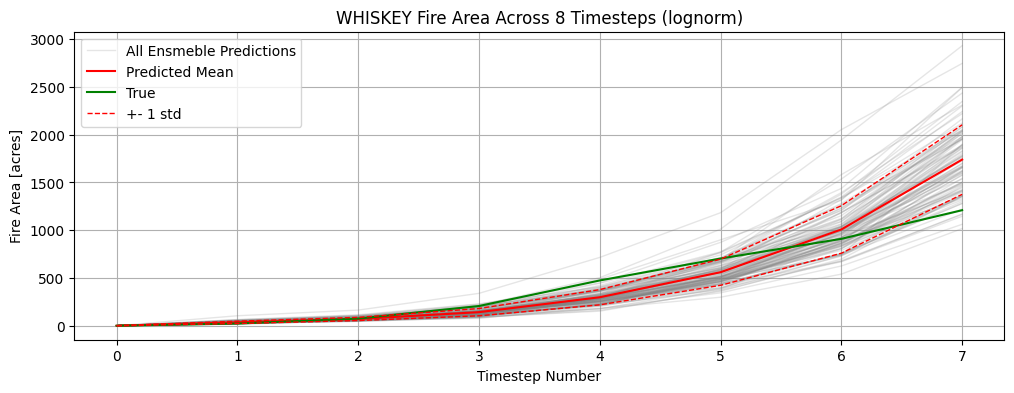

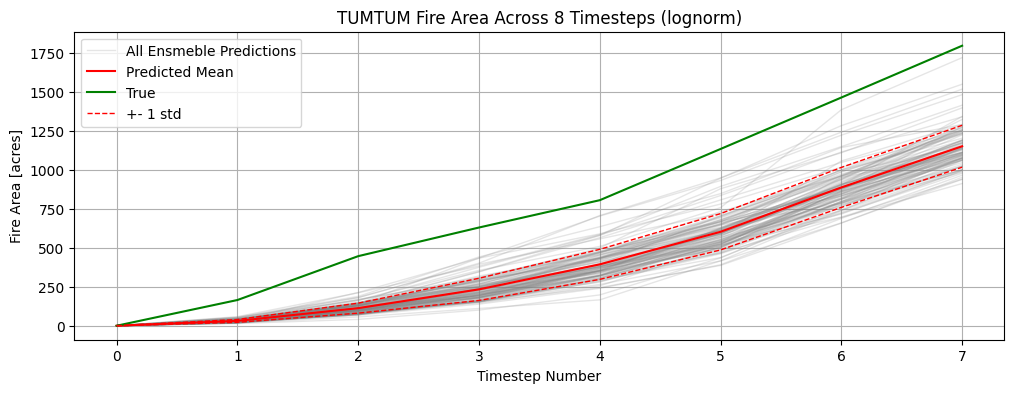

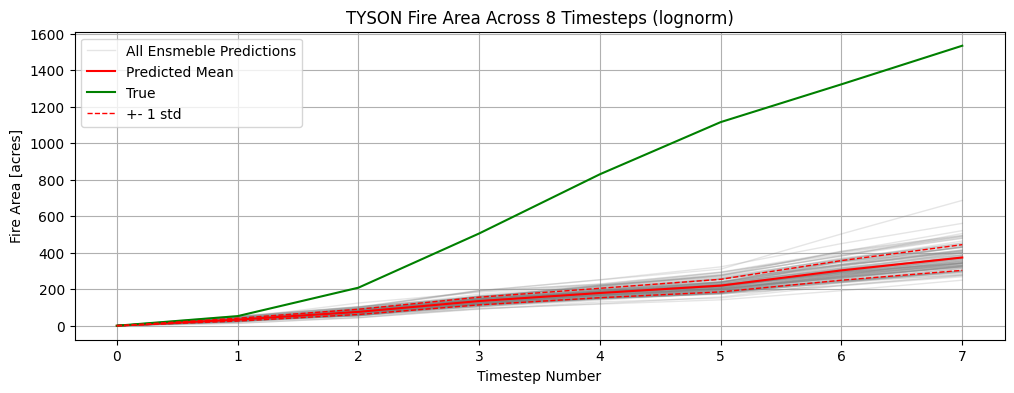

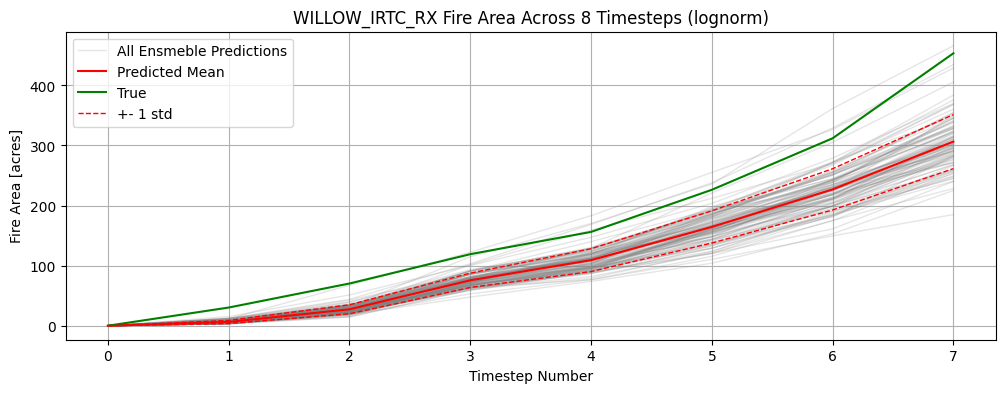

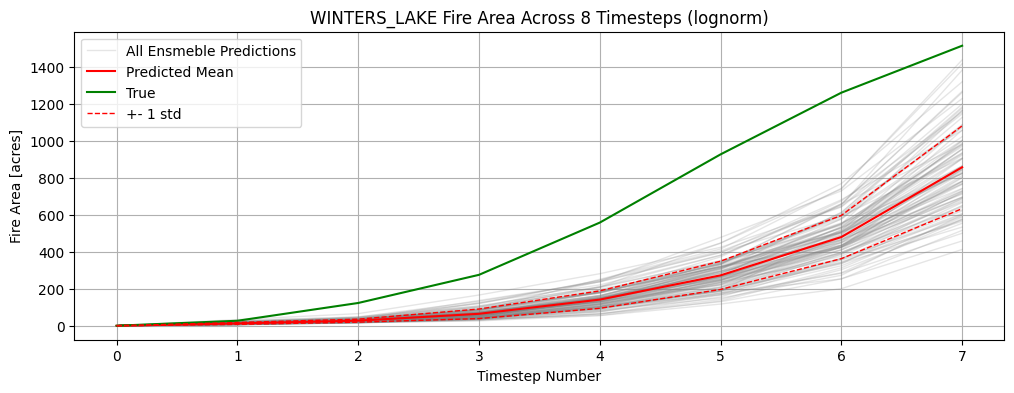

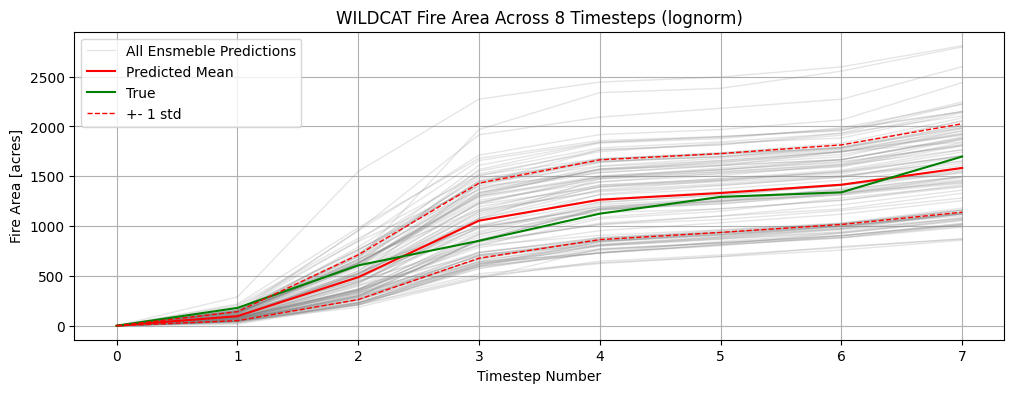

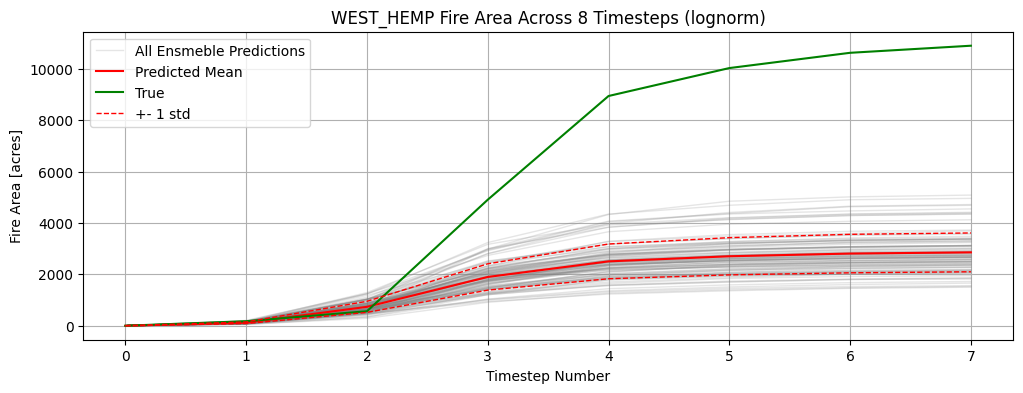

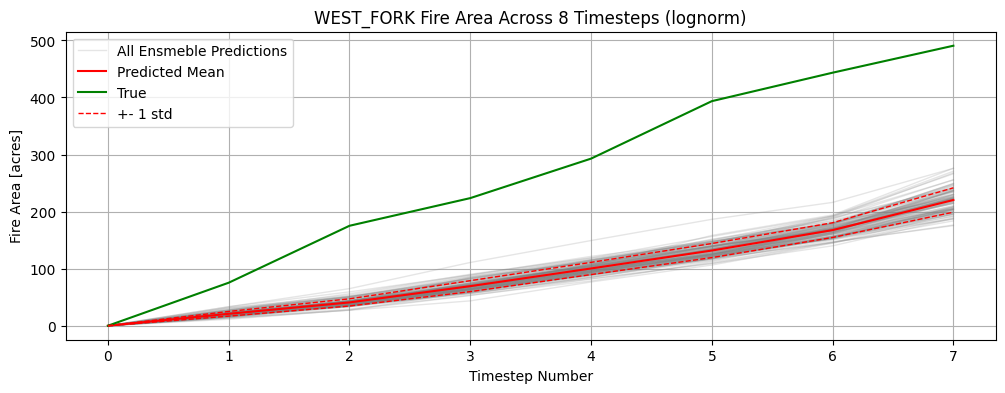

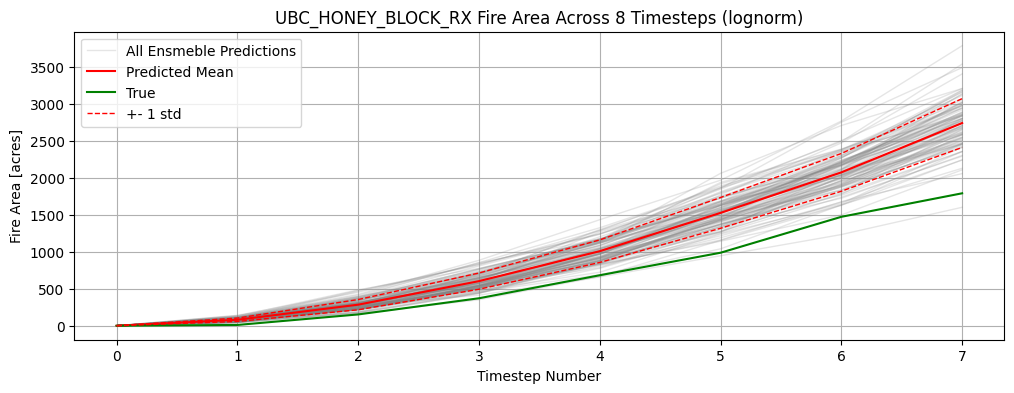

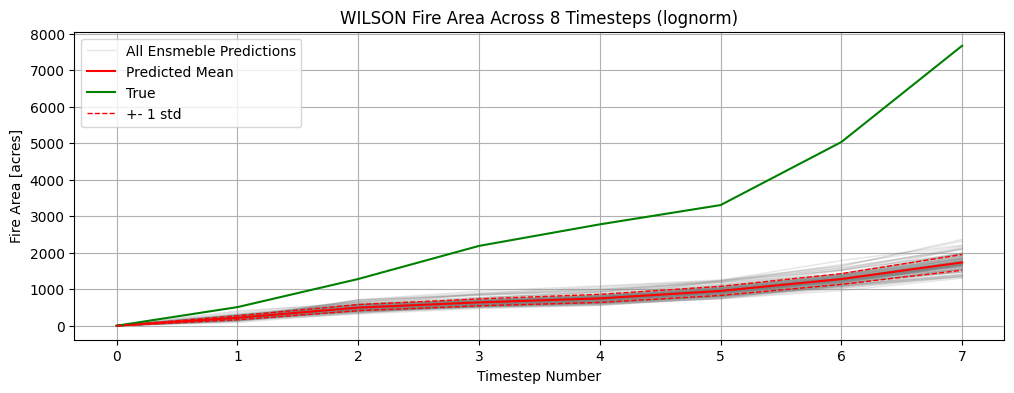

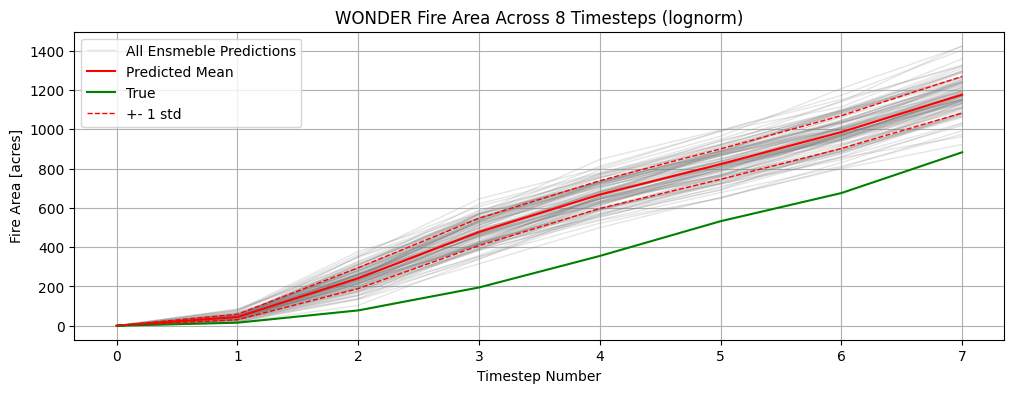

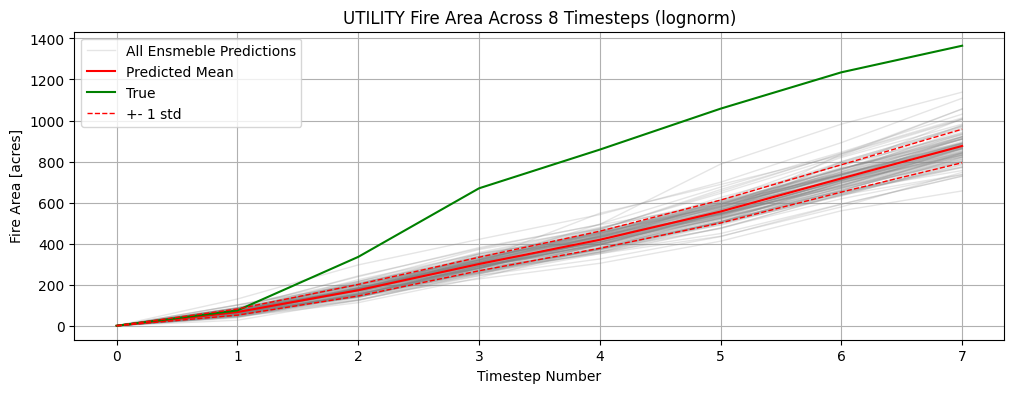

In [72]:
fires = ['WHISKEY', 'TUMTUM', 'TYSON', 'WILLOW_IRTC_RX', 'WINTERS_LAKE', 'WILDCAT', 'WEST_HEMP', 'WEST_FORK', 'UBC_HONEY_BLOCK_RX', 'WILSON', 'WONDER', 'UTILITY']
for fire_name in fires:
    fire_area_matrix = np.load(f'/Users/isaaclee/Wildfire_Research/lognorm_multiple_recursive_wildfire_results/depth_4_epochs_10000_schedule_VE_sigma_2/{fire_name}_fire_area_matrix.npz')
    fire_area_growth_matrix = fire_area_matrix['arr_0']
    #print(fire_area_growth_matrix.shape)
    area = np.sum(fire_area_growth_matrix[:, :, 2], axis=0)
    #print(area)
    # print(f"Final predicted mean area: {np.mean(area)}")
    pred_area = np.mean(area)

    condition_matrix = np.load(f"/Users/isaaclee/Wildfire_Research/validation_case_data_and_preparation/test_fire_data_npy/{fire_name}_validation_case_data.npy")
    real_fire_area_growth = condition_matrix[:, 2]

    target_area = np.sum(real_fire_area_growth)
    # print(f"Target area: {target_area}")

    pred_fire_area = fire_area_growth_matrix.copy()
    mean_pred_fire_area = np.zeros(shape=(7))
    std_at_timestep = np.zeros(shape=(7))
    real_fire_area = real_fire_area_growth.copy()

    for i in range(1,7):
        pred_fire_area[i, :, 2] = fire_area_growth_matrix[i, :, 2] + pred_fire_area[i-1, :, 2]
        real_fire_area[i] = real_fire_area_growth[i] + real_fire_area[i-1]

    for i in range(0,7):
        mean_pred_fire_area[i] = np.mean(pred_fire_area[i, :, 2])
        std_at_timestep[i] = np.std(pred_fire_area[i, :, 2])

    zeros = np.zeros((1, 100, 3))
    pred_fire_area = np.concatenate((zeros, pred_fire_area), axis=0)
    pred_fire_area = pred_fire_area[:, :, 2]
    mean_pred_fire_area = np.insert(mean_pred_fire_area, 0, 0)
    std_at_timestep = np.insert(std_at_timestep, 0, 0)
    real_fire_area = np.insert(real_fire_area, 0, 0)

    # print(f"Real fire area {real_fire_area}")
    # print(f"Mean predicted fire area {mean_pred_fire_area}")

    area_plus_1std  = mean_pred_fire_area + std_at_timestep
    area_minus_1std = mean_pred_fire_area - std_at_timestep

    plt.figure(figsize=(12,4))
    plt.title(f'{fire_name} Fire Area Across 8 Timesteps (lognorm)')
    plt.xlabel('Timestep Number')
    plt.xticks(range(0, 8))
    plt.ylabel('Fire Area [acres]')
    plt.grid(True)
    for i in range(0,100):
        if i == 0:
            plt.plot(pred_fire_area[:, i], color='gray', alpha=0.2, linewidth=1, label='All Ensmeble Predictions')
        else:
            plt.plot(pred_fire_area[:, i], alpha=0.2, linewidth=1, color='gray')
    plt.plot(mean_pred_fire_area, color='red', label='Predicted Mean')
    plt.plot(real_fire_area, color='green', label='True')
    plt.plot(area_plus_1std, color='red', alpha=1, linewidth=1, linestyle='dashed', label='+- 1 std')
    plt.plot(area_minus_1std, color='red', alpha=1, linewidth=1, linestyle='dashed')
    plt.legend()
    plt.show()